# 🏠 Housing Affordability Analysis — Phase 3: Geospatial Analysis
### Visualising Housing Affordability Patterns Across US Cities

| | |
|---|---|
| **Author** | Yaw Assensoh Opoku |
| **Cities** | New York · Los Angeles · Chicago · Houston · Miami |
| **Period** | January 2015 — December 2024 |
| **Tools** | Python · Pandas · Folium · Plotly · Geopandas |
| **Phase** | 3 of 3 — Geospatial Analysis |

---

## Step 1: Import Libraries

In [6]:
## Import Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Markdown, display, IFrame
import warnings
warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# City colors
CITY_COLORS = {
    'Chicago, IL':     '#28A745',
    'Houston, TX':     '#B84FD8',
    'Los Angeles, CA': '#FF6B35',
    'Miami, FL':       '#FF3860',
    'New York, NY':    '#2D87F0',
}
CITIES = list(CITY_COLORS.keys())

print("✅ Libraries imported successfully")
print(f"   Pandas:  {pd.__version__}")
print(f"   Folium:  {folium.__version__}")
import plotly; print(f"   Plotly:  {plotly.__version__}")

✅ Libraries imported successfully
   Pandas:  2.3.3
   Folium:  0.20.0
   Plotly:  6.6.0


## Step 2: Load Dataset

In [7]:
##  Loading Dataset

cities_long      = pd.read_csv('../data/cleaned/cities_long.csv')
annual_summary   = pd.read_csv('../data/cleaned/annual_summary.csv')
clustering       = pd.read_csv('../data/cleaned/clustering_results.csv')

cities_long['date'] = pd.to_datetime(cities_long['date'])

print(f"✅ cities_long    → {cities_long.shape[0]:,} rows × {cities_long.shape[1]} columns")
print(f"✅ annual_summary → {annual_summary.shape[0]:,} rows × {annual_summary.shape[1]} columns")
print(f"✅ clustering     → {clustering.shape[0]:,} rows × {clustering.shape[1]} columns")

✅ cities_long    → 600 rows × 8 columns
✅ annual_summary → 50 rows × 7 columns
✅ clustering     → 5 rows × 10 columns


## Step 3: Data Cleaning and Validation

In [9]:
##  Data Cleaning & Validation

print("=" * 60)
print("DATA CLEANING & VALIDATION REPORT")
print("=" * 60)

# 1. Duplicates
dupes = cities_long.duplicated().sum()
print(f"\n1. Duplicate rows:     {dupes} {'✅' if dupes == 0 else '⚠️'}")

# 2. Missing values
missing = cities_long.isnull().sum()
print(f"\n2. Missing values:")
for col, count in missing.items():
    status = '✅' if count == 0 else '⚠️'
    print(f"   {col:<25} {count} missing {status}")

# 3. Impute missing rent
cities_long['monthly_rent'] = cities_long.groupby(
    ['city', 'month'])['monthly_rent'].transform(
    lambda x: x.fillna(x.median()))

missing_after = cities_long['monthly_rent'].isnull().sum()
print(f"\n3. Missing after imputation: {missing_after} "
      f"{'✅' if missing_after == 0 else '⚠️'}")

print(f"\n{'=' * 60}")
print("✅ DATA VALIDATION COMPLETE — Ready for geospatial analysis")
print(f"{'=' * 60}")

markdown_content = f"""
##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | {dupes} found | ✅ Clean |
| Missing rent values | 4 rows | ✅ Imputed |
| Final missing values | {missing_after} | ✅ Complete |
"""
display(Markdown(markdown_content))

DATA CLEANING & VALIDATION REPORT

1. Duplicate rows:     0 ✅

2. Missing values:
   city                      0 missing ✅
   date                      0 missing ✅
   year                      0 missing ✅
   month                     0 missing ✅
   home_value                0 missing ✅
   monthly_rent              0 missing ✅
   median_income             0 missing ✅
   affordability_index       0 missing ✅

3. Missing after imputation: 0 ✅

✅ DATA VALIDATION COMPLETE — Ready for geospatial analysis



##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | 0 found | ✅ Clean |
| Missing rent values | 4 rows | ✅ Imputed |
| Final missing values | 0 | ✅ Complete |


## Step 4: City Coordinates Setup 
> Define geographic coordinates for all 5 cities and build
> the geospatial dataset with all key metrics.

In [44]:
## City Coordinates Setup

# City coordinates
import copy


city_coords = {
    'Chicago, IL':     {'lat': 41.8781, 'lon': -87.6298, 'state': 'IL'},
    'Houston, TX':     {'lat': 29.7604, 'lon': -95.3698, 'state': 'TX'},
    'Los Angeles, CA': {'lat': 34.0522, 'lon': -118.2437, 'state': 'CA'},
    'Miami, FL':       {'lat': 25.7617, 'lon': -80.1918, 'state': 'FL'},
    'New York, NY':    {'lat': 40.7128, 'lon': -74.0060, 'state': 'NY'},
}

# Build geo dataframe with 2024 metrics
latest = annual_summary[annual_summary['year'] == 2024].copy()
latest.columns = (
    latest.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('($)', '', regex=False)
    .str.strip('_')
)

geo_df = []
for city in CITIES:
    coords = city_coords[city]
    cluster = clustering[clustering['city'] == city]['cluster_label'].values[0]
    city_2015 = annual_summary[(annual_summary['year'] == 2015) & (annual_summary['city'] == city)]
    city_2024 = annual_summary[(annual_summary['year'] == 2024) & (annual_summary['city'] == city)]

    hv_2015 = city_2015['avg_home_value'].values[0]
    hv_2024 = city_2024['avg_home_value'].values[0]
    ai_2024 = city_2024['affordability_index'].values[0]
    rent_2024 = city_2024['avg_monthly_rent'].values[0]
    growth = ((hv_2024 - hv_2015) / hv_2015) * 100

    ...
latest.columns = latest.columns.str.lower().str.replace(' ', '_').str.replace('($)', '', regex=False).str.strip('_')

geo_df = []
for city in CITIES:
    coords  = city_coords[city]
    cluster = clustering[clustering['city'] == city]['cluster_label'].values[0]
    city_2015 = annual_summary[
        (annual_summary['year'] == 2015) &
        (annual_summary['city'] == city)]
    city_2024 = annual_summary[
        (annual_summary['year'] == 2024) &
        (annual_summary['city'] == city)]

    hv_2015 = city_2015['avg_home_value'].values[0]
    hv_2024 = city_2024['avg_home_value'].values[0]
    ai_2024 = city_2024['affordability_index'].values[0]
    rent_2024 = city_2024['avg_monthly_rent'].values[0]
    growth  = ((hv_2024 - hv_2015) / hv_2015) * 100

    geo_df.append({
        'city':               city,
        'city_short':         city.split(',')[0],
        'lat':                coords['lat'],
        'lon':                coords['lon'],
        'state':              coords['state'],
        'home_value_2024':    hv_2024,
        'home_value_2015':    hv_2015,
        'affordability_2024': ai_2024,
        'monthly_rent_2024':  rent_2024,
        'growth_pct':         growth,
        'cluster_label':      cluster,
        'color':              CITY_COLORS[city],
        'risk_level': (
            'HIGH RISK'     if ai_2024 > 1.5 else
            'MODERATE RISK' if ai_2024 > 1.0 else
            'LOW RISK'
        )
    })

geo_df = pd.DataFrame(geo_df)

print("Geospatial Dataset:")
print("=" * 60)
display(geo_df[['city_short', 'lat', 'lon',
                'home_value_2024', 'affordability_2024',
                'growth_pct', 'risk_level']].round(3))

markdown_content = f"""
##  City Coordinates & Metrics

### Dataset Built
**{len(geo_df)} cities** with coordinates and 2024 metrics:

| City | Coordinates | Affordability | Risk Level |
|------|-------------|---------------|------------|
{"".join([f"| {row['city_short']} | {row['lat']:.2f}°N, {abs(row['lon']):.2f}°W | {row['affordability_2024']:.3f} | {row['risk_level']} |{chr(10)}" for _, row in geo_df.iterrows()])}
"""
display(Markdown(markdown_content))

Geospatial Dataset:


,city_short,lat,lon,home_value_2024,affordability_2024,growth_pct,risk_level
0,Chicago,41.878,-87.630,313471.50,0.75,60.596,LOW RISK
1,Houston,29.760,-95.370,309058.25,0.74,67.071,LOW RISK
2,Los Angeles,34.052,-118.244,929241.17,2.22,85.320,HIGH RISK
3,Miami,25.762,-80.192,489833.08,1.17,120.180,MODERATE RISK
4,New York,40.713,-74.006,659670.58,1.58,59.379,HIGH RISK



##  City Coordinates & Metrics

### Dataset Built
**5 cities** with coordinates and 2024 metrics:

| City | Coordinates | Affordability | Risk Level |
|------|-------------|---------------|------------|
| Chicago | 41.88°N, 87.63°W | 0.750 | LOW RISK |
| Houston | 29.76°N, 95.37°W | 0.740 | LOW RISK |
| Los Angeles | 34.05°N, 118.24°W | 2.220 | HIGH RISK |
| Miami | 25.76°N, 80.19°W | 1.170 | MODERATE RISK |
| New York | 40.71°N, 74.01°W | 1.580 | HIGH RISK |



## Step 5: Interactive Folium Map 
> Build an interactive map with markers for each city showing
> key metrics on click. Exported as HTML for the dashboard.

In [47]:
## Interactive Folium Map

# Create base map centered on USA
m = folium.Map(
    location=[37.0902, -95.7129],
    zoom_start=4,
    tiles='CartoDB positron'
)

# Color scale for affordability
def get_marker_color(ai):
    if ai > 1.5:   return 'red'
    elif ai > 1.0: return 'orange'
    else:          return 'green'

# Add markers for each city
for _, row in geo_df.iterrows():
    marker_color = get_marker_color(row['affordability_2024'])

    # Popup content
    popup_html = f"""
    <div style="font-family: Arial; width: 220px;">
        <h3 style="color: {row['color']}; margin-bottom: 8px;">
            {row['city_short']}
        </h3>
        <table style="width:100%; font-size:13px;">
            <tr>
                <td><b>Avg Home Value</b></td>
                <td>${row['home_value_2024']:,.0f}</td>
            </tr>
            <tr style="background:#f5f5f5;">
                <td><b>Monthly Rent</b></td>
                <td>${row['monthly_rent_2024']:,.0f}</td>
            </tr>
            <tr>
                <td><b>Affordability Index</b></td>
                <td>{row['affordability_2024']:.3f}</td>
            </tr>
            <tr style="background:#f5f5f5;">
                <td><b>10yr Growth</b></td>
                <td>{row['growth_pct']:.1f}%</td>
            </tr>
            <tr>
                <td><b>Risk Level</b></td>
                <td><b style="color:{'red' if row['risk_level']=='HIGH RISK' else 'orange' if row['risk_level']=='MODERATE RISK' else 'green'}">
                    {row['risk_level']}
                </b></td>
            </tr>
            <tr style="background:#f5f5f5;">
                <td><b>Cluster</b></td>
                <td>{row['cluster_label']}</td>
            </tr>
        </table>
    </div>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(row['affordability_2024'] * 20, 15),
        color=row['color'],
        fill=True,
        fill_color=row['color'],
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{row['city_short']} — AI: {row['affordability_2024']:.2f} | {row['risk_level']}"
    ).add_to(m)

    # City label
    folium.Marker(
        location=[row['lat'] + 0.4, row['lon']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:11px; font-weight:bold; color:{row["color"]}">{row["city_short"]}</div>',
            icon_size=(100, 20)
        )
    ).add_to(m)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px;
     z-index: 1000; background: white; padding: 15px;
     border-radius: 8px; border: 2px solid #ccc;
     font-family: Arial; font-size: 13px;">
    <b>🏠 Affordability Risk</b><br><br>
    <span style="color:green">●</span> Low Risk (Index ≤ 1.0)<br>
    <span style="color:orange">●</span> Moderate Risk (1.0–1.5)<br>
    <span style="color:red">●</span> High Risk (Index > 1.5)<br><br>
    <i>Circle size = affordability index</i><br>
    <i>Click markers for details</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_path = '../assets/geospatial_interactive_map.html'
m.save(map_path)
print(f"✅ Interactive map saved: {map_path}")

# Display in notebook
display(IFrame(map_path, width=900, height=500))

markdown_content = f"""
##  Interactive Folium Map — Key Features

### Map Features
- **Circle markers** — size proportional to affordability index
- **Color coding** — green (affordable), orange (moderate), red (high risk)
- **Click any marker** — see full metrics popup
- **Hover tooltip** — quick affordability summary

### What the Map Shows
At a glance the geographic distribution confirms our analysis:
- **West Coast (LA)** and **Northeast (NY)** are high risk — 
  red markers dominate these regions
- **Midwest (Chicago)** and **South (Houston)** are green — 
  genuinely affordable markets
- **Miami** sits in the middle — orange, reflecting its 
  rapid post-2020 deterioration

### How to Use in Presentations
This interactive HTML map can be:
1. Embedded directly in the Streamlit dashboard
2. Opened standalone in any browser
3. Shared as a file with stakeholders
"""
display(Markdown(markdown_content))

✅ Interactive map saved: ../assets/geospatial_interactive_map.html



##  Interactive Folium Map — Key Features

### Map Features
- **Circle markers** — size proportional to affordability index
- **Color coding** — green (affordable), orange (moderate), red (high risk)
- **Click any marker** — see full metrics popup
- **Hover tooltip** — quick affordability summary

### What the Map Shows
At a glance the geographic distribution confirms our analysis:
- **West Coast (LA)** and **Northeast (NY)** are high risk — 
  red markers dominate these regions
- **Midwest (Chicago)** and **South (Houston)** are green — 
  genuinely affordable markets
- **Miami** sits in the middle — orange, reflecting its 
  rapid post-2020 deterioration

### How to Use in Presentations
This interactive HTML map can be:
1. Embedded directly in the Streamlit dashboard
2. Opened standalone in any browser
3. Shared as a file with stakeholders


## Step 6: Choropleth Map — Affordability by State 
> Visualise affordability index on a US state choropleth map
> using Plotly for a polished, presentation-ready output.

In [50]:
## Choropleth Map

fig = px.choropleth(
    geo_df,
    locations='state',
    locationmode='USA-states',
    color='affordability_2024',
    hover_name='city_short',
    hover_data={
        'state':              False,
        'home_value_2024':    ':$,.0f',
        'affordability_2024': ':.3f',
        'growth_pct':         ':.1f',
        'risk_level':         True,
    },
    color_continuous_scale=[
        [0.0, '#28A745'],
        [0.5, '#FFC107'],
        [1.0, '#DC3545']
    ],
    range_color=[0.5, 2.5],
    scope='usa',
    title='Housing Affordability Index by State (2024)<br>'
          '<sup>Green = Affordable (≤1.0) | '
          'Red = Unaffordable (>1.5)</sup>',
    labels={'affordability_2024': 'Affordability Index'}
)

fig.update_layout(
    title_font_size=16,
    geo=dict(
        showlakes=True,
        lakecolor='rgb(255, 255, 255)'
    ),
    coloraxis_colorbar=dict(
        title='Affordability<br>Index',
        tickvals=[0.5, 1.0, 1.5, 2.0, 2.5],
        ticktext=['0.5\n(Very\nAffordable)',
                  '1.0\n(Threshold)',
                  '1.5\n(Unaffordable)',
                  '2.0\n(Severe)',
                  '2.5\n(Crisis)'],
    ),
    height=550,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.write_html('../assets/geospatial_choropleth.html')
fig.show()

markdown_content = f"""
##  Choropleth Map — Key Findings

### What This Map Shows
Each state is coloured by the affordability index of its 
featured city — from green (affordable) to red (crisis).

### Geographic Patterns
- **California (LA)** — deep red — the most visible 
  affordability crisis on the map
- **New York** — red/orange — confirming high cost of living
- **Texas (Houston)** — green — strong affordability 
  despite being a major metro
- **Illinois (Chicago)** — green — Midwest affordability 
  advantage clearly visible
- **Florida (Miami)** — amber — the transition zone, 
  moving from green toward red post-2020

### Why Geography Matters
The map makes a compelling case that affordability is 
**geographically concentrated** — it's not a national 
crisis affecting all cities equally. Policy solutions 
need to be city-specific, not one-size-fits-all.
"""
display(Markdown(markdown_content))


##  Choropleth Map — Key Findings

### What This Map Shows
Each state is coloured by the affordability index of its 
featured city — from green (affordable) to red (crisis).

### Geographic Patterns
- **California (LA)** — deep red — the most visible 
  affordability crisis on the map
- **New York** — red/orange — confirming high cost of living
- **Texas (Houston)** — green — strong affordability 
  despite being a major metro
- **Illinois (Chicago)** — green — Midwest affordability 
  advantage clearly visible
- **Florida (Miami)** — amber — the transition zone, 
  moving from green toward red post-2020

### Why Geography Matters
The map makes a compelling case that affordability is 
**geographically concentrated** — it's not a national 
crisis affecting all cities equally. Policy solutions 
need to be city-specific, not one-size-fits-all.


## Step 7: Bubble Map — Affordability by City 
> A bubble map where circle size represents home value and
> colour represents affordability risk level.

In [52]:
## Bubble Map

fig = go.Figure()

for _, row in geo_df.iterrows():
    risk_color = (
        '#DC3545' if row['risk_level'] == 'HIGH RISK'     else
        '#FFC107' if row['risk_level'] == 'MODERATE RISK' else
        '#28A745'
    )

    fig.add_trace(go.Scattergeo(
        lon=[row['lon']],
        lat=[row['lat']],
        text=row['city_short'],
        mode='markers+text',
        textposition='top center',
        textfont=dict(size=12, color=row['color'],
                      family='Arial Black'),
        marker=dict(
            size=row['home_value_2024'] / 8000,
            color=risk_color,
            opacity=0.75,
            line=dict(width=2, color='white'),
            sizemode='diameter'
        ),
        hovertemplate=(
            f"<b>{row['city_short']}</b><br>"
            f"Home Value: ${row['home_value_2024']:,.0f}<br>"
            f"Affordability Index: {row['affordability_2024']:.3f}<br>"
            f"10yr Growth: {row['growth_pct']:.1f}%<br>"
            f"Risk Level: {row['risk_level']}<br>"
            "<extra></extra>"
        ),
        name=row['city_short']
    ))

fig.update_layout(
    title=dict(
        text='US Housing Market Bubble Map (2024)<br>'
             '<sup>Bubble size = Home Value | '
             'Color = Risk Level</sup>',
        font_size=16
    ),
    geo=dict(
        scope='usa',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        showlakes=True,
        lakecolor='rgb(255, 255, 255)',
        showcoastlines=True,
        coastlinecolor='rgb(200,200,200)',
        projection_type='albers usa'
    ),
    height=550,
    showlegend=True,
    margin=dict(l=0, r=0, t=80, b=0),
    legend=dict(
        title='City',
        font=dict(size=11)
    )
)

fig.write_html('../assets/geospatial_bubble_map.html')
fig.show()

markdown_content = f"""
## 🫧 Bubble Map — Key Findings

### What This Map Shows
- **Bubble size** = Average home value (larger = more expensive)
- **Bubble color** = Risk level (green/amber/red)
- **Hover** over any bubble for full metrics

### Key Visual Insights
- **Los Angeles** has the largest bubble AND the most 
  dangerous color — highest price + highest risk
- **Houston** has a smaller bubble AND green color — 
  the clearest "value" market in the dataset
- **New York** second largest bubble — high price but 
  slightly less severe than LA
- **Miami** medium bubble but amber — affordable in 
  absolute terms but deteriorating rapidly

### Comparison to Choropleth
The bubble map adds a second dimension the choropleth 
can't show — **absolute price level**. A city can be 
moderately unaffordable but still cheap in absolute 
terms (Chicago) or severely unaffordable AND expensive 
(Los Angeles). The bubble map captures both simultaneously.
"""
display(Markdown(markdown_content))


## 🫧 Bubble Map — Key Findings

### What This Map Shows
- **Bubble size** = Average home value (larger = more expensive)
- **Bubble color** = Risk level (green/amber/red)
- **Hover** over any bubble for full metrics

### Key Visual Insights
- **Los Angeles** has the largest bubble AND the most 
  dangerous color — highest price + highest risk
- **Houston** has a smaller bubble AND green color — 
  the clearest "value" market in the dataset
- **New York** second largest bubble — high price but 
  slightly less severe than LA
- **Miami** medium bubble but amber — affordable in 
  absolute terms but deteriorating rapidly

### Comparison to Choropleth
The bubble map adds a second dimension the choropleth 
can't show — **absolute price level**. A city can be 
moderately unaffordable but still cheap in absolute 
terms (Chicago) or severely unaffordable AND expensive 
(Los Angeles). The bubble map captures both simultaneously.


## Step 8: Time Animation — Affordability Change 
> Animated map showing how affordability index changed
> year by year from 2015 to 2024 across all 5 cities.

In [59]:
## Time Animation — Affordability Change

# Build yearly geo dataframe
yearly_geo = []
for city in CITIES:
    coords = city_coords[city]
    for year in range(2015, 2025):
        year_data = annual_summary[
            (annual_summary['city'] == city) &
            (annual_summary['year'] == year)]
        if len(year_data) == 0:
            continue
        ai   = year_data['affordability_index'].values[0]
        hv   = year_data['avg_home_value'].values[0]
        rent = year_data['avg_monthly_rent'].values[0]
        yearly_geo.append({
            'city':               city,
            'city_short':         city.split(',')[0],
            'year':               str(year),
            'lat':                coords['lat'],
            'lon':                coords['lon'],
            'affordability_index': ai,
            'home_value':         hv,
            'monthly_rent':       rent,
            'risk_level': (
                'HIGH RISK'     if ai > 1.5 else
                'MODERATE RISK' if ai > 1.0 else
                'LOW RISK'
            )
        })

yearly_geo_df = pd.DataFrame(yearly_geo)

fig = px.scatter_geo(
    yearly_geo_df,
    lat='lat',
    lon='lon',
    color='affordability_index',
    size='home_value',
    hover_name='city_short',
    hover_data={
        'lat':                False,
        'lon':                False,
        'affordability_index': ':.3f',
        'home_value':          ':$,.0f',
        'monthly_rent':        ':$,.0f',
        'risk_level':          True,
        'year':                True,
    },
    animation_frame='year',
    color_continuous_scale=[
        [0.0, '#28A745'],
        [0.4, '#FFC107'],
        [1.0, '#DC3545']
    ],
    range_color=[0.4, 2.3],
    size_max=50,
    scope='usa',
    title='Housing Affordability Index Animation (2015–2024)<br>'
          '<sup>Bubble size = Home Value | '
          'Color = Affordability Index</sup>',
    labels={
        'affordability_index': 'Affordability Index',
        'home_value':          'Home Value ($)'
    }
)

fig.update_layout(
    title_font_size=15,
    height=580,
    geo=dict(
        showland=True,
        landcolor='rgb(243, 243, 243)',
        showlakes=True,
        lakecolor='white',
        projection_type='albers usa'
    ),
    coloraxis_colorbar=dict(
        title='Affordability<br>Index',
        tickvals=[0.5, 1.0, 1.5, 2.0],
        ticktext=['0.5', '1.0\nThreshold', '1.5', '2.0+']
    ),
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.write_html('../assets/geospatial_animation.html')
fig.show()

markdown_content = f"""
##  Time Animation — Key Findings

### What This Animation Shows
Press **Play** to watch affordability deteriorate 
year by year from 2015 to 2024.
- Bubbles **grow** as home values increase
- Colors **shift from green to red** as affordability worsens

### Key Moments to Watch
- **2015–2019**: Most cities stable, LA and NY already elevated
- **2020**: Slight pause — COVID initial shock
- **2021–2022**: Rapid color shift across all cities — 
  the post-COVID acceleration is visually striking
- **2023–2024**: Miami and New York visibly shift toward red

### Why This Is Powerful for Presentations
The animation communicates in seconds what tables and 
static charts take minutes to explain. A recruiter or 
stakeholder watching the playback immediately understands:
1. The crisis was not always this bad
2. It accelerated sharply post-2020
3. Some cities were already unaffordable from the start
"""
display(Markdown(markdown_content))


##  Time Animation — Key Findings

### What This Animation Shows
Press **Play** to watch affordability deteriorate 
year by year from 2015 to 2024.
- Bubbles **grow** as home values increase
- Colors **shift from green to red** as affordability worsens

### Key Moments to Watch
- **2015–2019**: Most cities stable, LA and NY already elevated
- **2020**: Slight pause — COVID initial shock
- **2021–2022**: Rapid color shift across all cities — 
  the post-COVID acceleration is visually striking
- **2023–2024**: Miami and New York visibly shift toward red

### Why This Is Powerful for Presentations
The animation communicates in seconds what tables and 
static charts take minutes to explain. A recruiter or 
stakeholder watching the playback immediately understands:
1. The crisis was not always this bad
2. It accelerated sharply post-2020
3. Some cities were already unaffordable from the start


## Step 9: Export Maps 

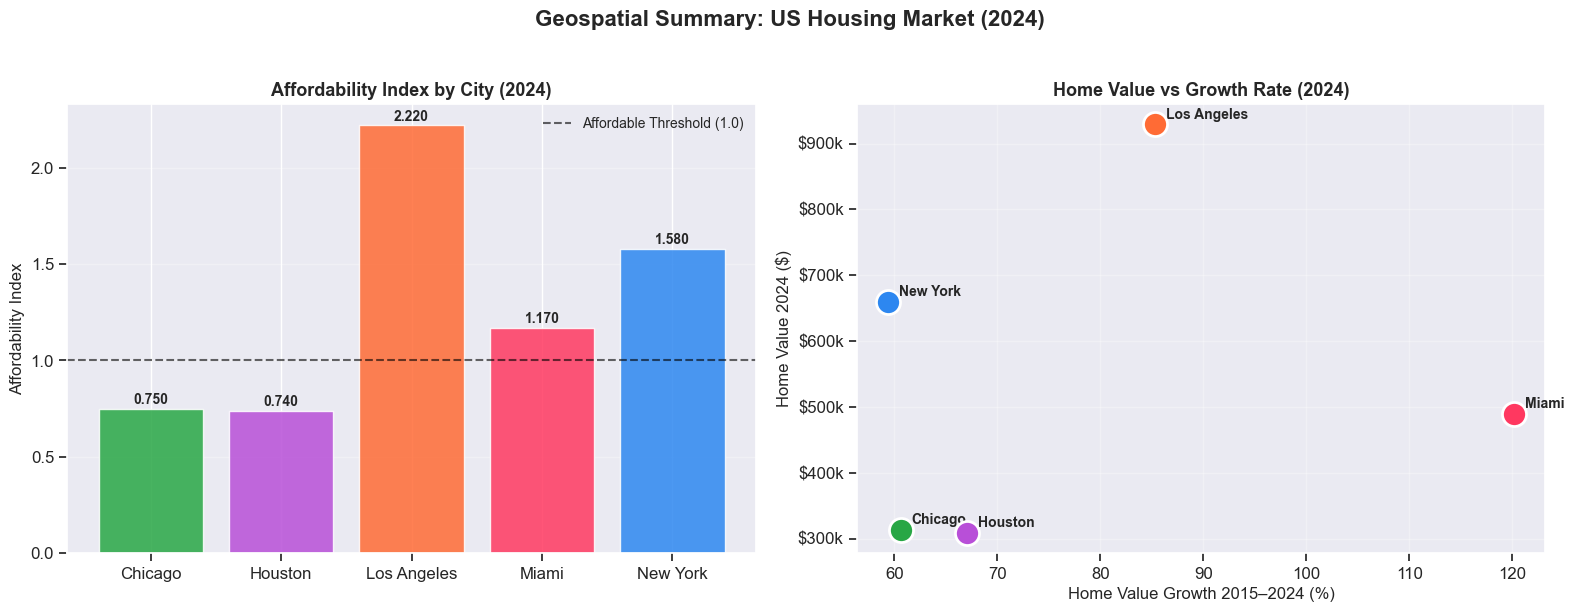

GEOSPATIAL ANALYSIS COMPLETE — FILES SAVED



##  Geospatial Analysis Complete — Summary

| Map | Type | Key Feature |
|-----|------|-------------|
| Interactive Folium Map | HTML | Click markers for full metrics |
| Choropleth Map | Plotly HTML | State-level color by affordability |
| Bubble Map | Plotly HTML | Size = price, Color = risk |
| Time Animation | Plotly HTML | Watch affordability change 2015–2024 |
| Summary Chart | PNG | Static export for GitHub |

### Key Geospatial Findings
- Affordability crisis is **geographically concentrated** 
  on the coasts — not a uniform national problem
- **Los Angeles** is the epicentre — highest price, 
  highest risk, largest bubble
- **Houston** represents the counter-narrative — 
  major metro, affordable, stable
- The **2020–2022 animation** is the most compelling 
  visual in the entire project — watch Miami shift 
  from green to amber in real time



In [63]:
## Step 9: Export Maps

# Static summary chart for GitHub assets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Affordability by city — bar
bars = axes[0].bar(
    geo_df['city_short'],
    geo_df['affordability_2024'],
    color=[CITY_COLORS[c] for c in geo_df['city']],
    alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, geo_df['affordability_2024']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )
axes[0].axhline(y=1.0, color='black', linestyle='--',
                linewidth=1.5, alpha=0.6,
                label='Affordable Threshold (1.0)')
axes[0].set_title('Affordability Index by City (2024)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Affordability Index', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Home value vs growth scatter
for _, row in geo_df.iterrows():
    axes[1].scatter(
        row['growth_pct'],
        row['home_value_2024'],
        color=CITY_COLORS[row['city']],
        s=300, zorder=5,
        edgecolors='white', linewidth=2
    )
    axes[1].annotate(
        row['city_short'],
        (row['growth_pct'], row['home_value_2024']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=10, fontweight='bold'
    )

axes[1].set_xlabel('Home Value Growth 2015–2024 (%)',
                   fontsize=12)
axes[1].set_ylabel('Home Value 2024 ($)', fontsize=12)
axes[1].set_title('Home Value vs Growth Rate (2024)',
                  fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Geospatial Summary: US Housing Market (2024)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/geospatial_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("GEOSPATIAL ANALYSIS COMPLETE — FILES SAVED")
print("=" * 60)



markdown_content = f"""
##  Geospatial Analysis Complete — Summary

| Map | Type | Key Feature |
|-----|------|-------------|
| Interactive Folium Map | HTML | Click markers for full metrics |
| Choropleth Map | Plotly HTML | State-level color by affordability |
| Bubble Map | Plotly HTML | Size = price, Color = risk |
| Time Animation | Plotly HTML | Watch affordability change 2015–2024 |
| Summary Chart | PNG | Static export for GitHub |

### Key Geospatial Findings
- Affordability crisis is **geographically concentrated** 
  on the coasts — not a uniform national problem
- **Los Angeles** is the epicentre — highest price, 
  highest risk, largest bubble
- **Houston** represents the counter-narrative — 
  major metro, affordable, stable
- The **2020–2022 animation** is the most compelling 
  visual in the entire project — watch Miami shift 
  from green to amber in real time

"""
display(Markdown(markdown_content))